# Fainter-fatter test: admom size & ellipticity of simulated stars vs magnitude (repeated noise realizations)

Same as `fainter_fatter_admom_test.ipynb`, but each star in the catalog is measured
`N_REPS` times with independent random noise realizations (same flux, same PSF, same
position), so the statistics per magnitude bin are boosted without changing the catalog
itself.

For each star in the SuperBIT detection catalog, repeated `N_REPS` times:
- star = `galsim.DeltaFunction(flux)` (flux from the catalog),
- convolved with a Gaussian PSF so any size trend is not from a real PSF,
- plus constant Gaussian noise (independent draw per repeat),
- size `T` and ellipticity `e1, e2` measured with adaptive moments (`get_admoms`).

(Refs: Refregier+ 2012, Melchior & Viola 2012.)

In [1]:
import numpy as np
import galsim
import matplotlib.pyplot as plt
from astropy.table import Table
from concurrent.futures import ProcessPoolExecutor

try:
    from superbit_lensing.utils import get_admoms, get_galsim_tanwcs
except ImportError:
    from shearnet.utils.superbit import get_admoms, get_galsim_tanwcs


def parallel_map(fn, n, workers, chunks_per_worker=8):
    if workers is None or workers <= 1:
        return [fn(i) for i in range(n)]
    chunk = max(1, n // (workers * chunks_per_worker))
    with ProcessPoolExecutor(max_workers=workers) as ex:
        return list(ex.map(fn, range(n), chunksize=chunk))

In [2]:
# config
CAT_PATH    = "/home/adfield/ShearNet/simulated_detection_truth_backcast_unit_fiducial_dec04.fits"
PSF_FWHM    = 0.43                # arcsec, Gaussian PSF
PIXEL_SCALE = 0.141              # arcsec / pixel
STAMP       = 53                 # pixels
HIGH_NOISE_SD    = 15.98        # constant Gaussian noise
LOW_NOISE_SD     = 2.0
SEED        = 42
FLUX_SCALE  = 300 * 36 / 0.343   # crates_b -> electrons
MAG_ZP      = 29.146             # flux -> mag zeropoint
N_MAX       = 100000             # subsample cap for speed (stars, before repeats)
N_BINS      = 20
WORKERS     = 32
N_REPS      = 10                 # independent noise realizations per star

# ---- SuperBIT PSF selection -------------------------------------------------
# "auto"    -> search over RANDOM field positions: at each position, measure every
#              superbit_psf_emp*.psf file's NOISE-FREE admom T and |e|; if any
#              (file, position) lands inside BOTH target ranges below, take it
#              (closest to the box centre if several); otherwise draw a new random
#              position and survey all files again, up to AUTO_MAX_ROUNDS rounds.
# "best"    -> superbit_psf_emp01.psf
# "worst"   -> highest serial number
# "optical" -> galsim OpticalPSF SuperBIT model, sheared by PSF_SHEAR_OPTICAL
PSF_KIND        = "auto"
AUTO_MAX_ROUNDS = 75              # random positions to try before giving up (only needed for auto)
SUPERBIT_DIR    = "/home/adfield/weak_lensing/superbit-lensing-jax-test"

# Fig. 9 real-data target ranges for the NOISE-FREE PSF measurement (input value)
T_TARGET_RANGE = (0.069, 0.071)   # arcsec^2
E_TARGET_RANGE = (0.069, 0.071)   # |e| = hypot(e1, e2), reduced

PSF_SHEAR_OPTICAL = (0.052, 0.052)  # shear applied to the optical PSF (bit_psf args)

In [3]:
# star fluxes from the detection catalog
cat  = Table.read(CAT_PATH)
flux = np.asarray(cat["crates_b"], dtype=float) * FLUX_SCALE
flux = flux[np.isfinite(flux) & (flux > 0)]

# convert to magnitude, then keep only requested range
mag = MAG_ZP - 2.5 * np.log10(flux)
mag_min, mag_max = 13.8, 21.2
sel = (mag >= mag_min) & (mag <= mag_max)
flux = flux[sel]
mag  = mag[sel]

# optional subsample cap (applied to the catalog, before repeating)
rng = np.random.default_rng(SEED)
if len(flux) > N_MAX:
    idx = rng.choice(len(flux), N_MAX, replace=False)
    flux = flux[idx]
    mag  = mag[idx]

n_stars = len(flux)
n_meas  = n_stars * N_REPS

# each star repeated N_REPS times consecutively -> combined index i maps to
# star_idx = i // N_REPS, rep_idx = i % N_REPS
flux_rep = np.repeat(flux, N_REPS)
mag_rep  = np.repeat(mag, N_REPS)

print(f"{n_stars} stars x {N_REPS} reps = {n_meas} measurements | "
      f"flux [{flux.min():.1f}, {flux.max():.1f}] | mag [{mag.min():.2f}, {mag.max():.2f}]")

88859 stars x 10 reps = 888590 measurements | flux [1511.9, 1348806.0] | mag [13.82, 21.20]


In [4]:
# simulate each (star, repeat) and measure T, e1, e2 with adaptive moments
psf = galsim.Gaussian(fwhm=PSF_FWHM).shear(g1=0.052, g2=0.052)

def measure_gauss(i):
    f    = flux_rep[i]
    star = galsim.Convolve([galsim.DeltaFunction(flux=f), psf])
    im   = star.drawImage(nx=STAMP, ny=STAMP, scale=PIXEL_SCALE).array
    # independent per-(star,repeat) noise realization
    im   = im + np.random.default_rng(SEED * 1_000_003 + i).normal(0.0, HIGH_NOISE_SD, im.shape)
    res  = get_admoms(im, PIXEL_SCALE, reduced=True)
    if res["flags"] == 0:
        return res["T"], res["e1"], res["e2"]
    return np.nan, np.nan, np.nan

def measure_gauss_lo(i):
    f    = flux_rep[i]
    star = galsim.Convolve([galsim.DeltaFunction(flux=f), psf])
    im   = star.drawImage(nx=STAMP, ny=STAMP, scale=PIXEL_SCALE).array
    im   = im + np.random.default_rng(SEED * 1_000_003 + i).normal(0.0, LOW_NOISE_SD, im.shape)
    res  = get_admoms(im, PIXEL_SCALE, reduced=True)
    if res["flags"] == 0:
        return res["T"], res["e1"], res["e2"]
    return np.nan, np.nan, np.nan

Tarr, e1arr, e2arr = (np.asarray(a) for a in zip(*parallel_map(measure_gauss, n_meas, WORKERS)))
Tarr_lo, e1arr_lo, e2arr_lo = (np.asarray(a) for a in zip(*parallel_map(measure_gauss_lo, n_meas, WORKERS)))

print(f"admom succeeded on {np.isfinite(Tarr).sum()} / {len(Tarr)} measurements (high), "
      f"{np.isfinite(Tarr_lo).sum()} / {len(Tarr_lo)} (low)")

admom succeeded on 888528 / 888590 measurements (high), 888590 / 888590 (low)


In [5]:
# bin by magnitude (median + standard error). Uses mag_rep since Tarr etc. have
# n_stars * N_REPS entries (each star's magnitude repeated N_REPS times).
def binned(x, y, n_bins):
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    edges = np.linspace(x.min(), x.max(), n_bins + 1)
    idx = np.digitize(x, edges)
    cx, cy, ce = [], [], []
    for b in range(1, n_bins + 1):
        m = idx == b
        if m.sum() > 3:
            cx.append(np.median(x[m]))
            cy.append(np.median(y[m]))
            ce.append(np.std(y[m]) / np.sqrt(m.sum()))
    return np.array(cx), np.array(cy), np.array(ce)

mT,  T_med,  T_err  = binned(mag_rep, Tarr,          N_BINS)
m1, e1_med, e1_err  = binned(mag_rep, e1arr, N_BINS)
m2, e2_med, e2_err  = binned(mag_rep, e2arr, N_BINS)
eabs_arr = np.hypot(e1arr, e2arr)
mabs, eabs_med, eabs_err = binned(mag_rep, eabs_arr, N_BINS)

mT_lo,  T_med_lo,  T_err_lo  = binned(mag_rep, Tarr_lo,          N_BINS)
m1_lo, e1_med_lo, e1_err_lo  = binned(mag_rep, e1arr_lo, N_BINS)
m2_lo, e2_med_lo, e2_err_lo  = binned(mag_rep, e2arr_lo, N_BINS)
eabs_arr_lo = np.hypot(e1arr_lo, e2arr_lo)
mabs_lo, eabs_med_lo, eabs_err_lo = binned(mag_rep, eabs_arr_lo, N_BINS)

Saved -> fainter_fatter_admom_test_repeated.png


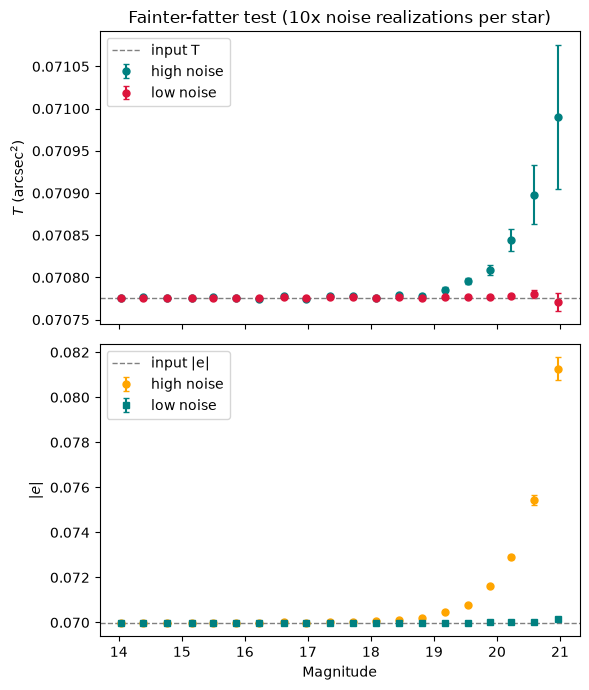

In [6]:
# plot: upper = T(mag), lower = |e1|,|e2|(mag)  (cf. Fig. 9)
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(6, 7), sharex=True)

ax0.errorbar(mT, T_med, yerr=T_err, fmt="o", color="teal", capsize=2, ms=5, label="high noise")
ax0.errorbar(mT_lo, T_med_lo, yerr=T_err_lo, fmt="o", color="crimson", capsize=2, ms=5, label="low noise")
ax0.set_ylabel(r"$T$ (arcsec$^2$)")
ax0.set_title(f"Fainter-fatter test ({N_REPS}x noise realizations per star)")
T_input = get_admoms(
    galsim.Convolve([galsim.DeltaFunction(flux=1.0), psf])
          .drawImage(nx=STAMP, ny=STAMP, scale=PIXEL_SCALE).array,
    PIXEL_SCALE, reduced=True)["T"]
ax0.axhline(T_input, color="gray", ls="--", lw=1, label="input T")
ax0.legend()

eabs_input = np.hypot(
    get_admoms(
        psf.drawImage(nx=STAMP, ny=STAMP, scale=PIXEL_SCALE).array,
        PIXEL_SCALE, reduced=True)["e1"],
    get_admoms(
        psf.drawImage(nx=STAMP, ny=STAMP, scale=PIXEL_SCALE).array,
        PIXEL_SCALE, reduced=True)["e2"]
)
ax1.axhline(eabs_input, color="gray", ls="--", lw=1, label="input |e|")

ax1.errorbar(mabs, eabs_med, yerr=eabs_err, fmt="o", color="orange", capsize=2, ms=5, label="high noise")
ax1.errorbar(mabs_lo, eabs_med_lo, yerr=eabs_err_lo, fmt="s", color="teal", capsize=2, ms=5, label="low noise")

ax1.set_ylabel(r"$|e|$")
ax1.set_xlabel("Magnitude")
ax1.legend()

plt.tight_layout()
# plt.savefig("fainter_fatter_admom_test_repeated.png", dpi=150, bbox_inches="tight")
print("Saved -> fainter_fatter_admom_test_repeated.png")

Same repeated-noise-realization approach, now with a real SuperBIT PSF instead of the
Gaussian. `PSF_KIND` (config cell) selects it: an **empirical `DES_PSFEx`** model —
`"best"` (emp01), `"worst"` (highest serial), or `"auto"` (iterate over **random field
positions**: at each position measure every `.psf` file's **noise-free** admom `T` and
`|e|`, and stop at the first (file, position) combo inside **both** Fig. 9 target
ranges — closest to the box centre if several qualify; a new random position is drawn
whenever none qualifies, up to `AUTO_MAX_ROUNDS`) — or the **`"optical"`** SuperBIT
model (OpticalPSF + pointing jitter, the advisor's `bit_psf`). The chosen PSF is
evaluated at its chosen sky point and reused for every star/repeat; its noise-free
`T`/`|e|` are printed against the target ranges.

In [7]:
# build the SuperBIT PSF per PSF_KIND, then simulate each (star, repeat)
import os
import re
from glob import glob
import galsim.des

gsp = galsim.GSParams(maximum_fft_size=32768)
IMG_XSIZE, IMG_YSIZE, MARGIN = 9600, 6400, 500

pos_rng = np.random.default_rng(SEED + 1)

def _draw_position():
    x = int(pos_rng.integers(MARGIN, IMG_XSIZE - MARGIN))
    y = int(pos_rng.integers(MARGIN, IMG_YSIZE - MARGIN))
    return x, y

def _noise_free_Te(psf_obj):
    """NOISE-FREE admom (T, |e|) of a point source through psf_obj -- the 'input value'."""
    im = galsim.Convolve([galsim.DeltaFunction(flux=1.0), psf_obj], gsparams=gsp) \
               .drawImage(nx=STAMP, ny=STAMP, scale=PIXEL_SCALE).array
    r = get_admoms(im, PIXEL_SCALE, reduced=True)
    return r["T"], np.hypot(r["e1"], r["e2"])

def _in(v, rng_):
    return rng_[0] <= v <= rng_[1]

if PSF_KIND == "optical":
    # Constants verbatim from s-Sayan/ngmix examples/metacal/metacal_psf_response.py.
    _ab = np.zeros(38)
    _ab[4]  = -0.02474205
    _ab[11] = -0.01544329
    _ab[22] =  0.00199235
    _ab[26] =  0.00000017
    _ab[37] =  0.00000004
    jitter = galsim.Gaussian(flux=1.0, fwhm=0.467)
    optics = galsim.OpticalPSF(
        lam=475, diam=0.5, obscuration=0.380,
        nstruts=4, strut_angle=90 * galsim.degrees, strut_thick=0.087,
        aberrations=_ab,
    )
    psf_fixed = galsim.Convolve([jitter, optics]).shear(
        g1=PSF_SHEAR_OPTICAL[0], g2=PSF_SHEAR_OPTICAL[1]
    )
    psf_label = "optical"
else:
    # empirical PSFEx models, loaded ONCE; positions are evaluated per round below
    files = sorted(glob(os.path.join(SUPERBIT_DIR, "**", "superbit_psf_emp*.psf"),
                        recursive=True))
    _seen = set()
    files = [f for f in files
             if os.path.basename(f) not in _seen and not _seen.add(os.path.basename(f))]
    if not files:
        raise FileNotFoundError(f"no superbit_psf_emp*.psf found under {SUPERBIT_DIR}")
    _num = lambda f: int(re.search(r"emp(\d+)", os.path.basename(f)).group(1))
    files = sorted(files, key=_num)

    wcs = get_galsim_tanwcs()
    models = [galsim.des.DES_PSFEx(f, wcs=wcs) for f in files]

    def _survey(x, y, verbose=False):
        """Measure every file's noise-free (T, |e|) at position (x, y)."""
        cands = []
        for f, m in zip(files, models):
            p = m.getPSF(galsim.PositionD(x, y))
            T, e = _noise_free_Te(p)
            ok = _in(T, T_TARGET_RANGE) and _in(e, E_TARGET_RANGE)
            cands.append((f, p, T, e, ok))
            if verbose:
                flag = "  <-- IN Fig.9 range" if ok else ""
                print(f"  {os.path.basename(f):32s} T = {T:.4f} arcsec^2   |e| = {e:.4f}{flag}")
        return cands

    Tc, ec = 0.5 * sum(T_TARGET_RANGE), 0.5 * sum(E_TARGET_RANGE)
    _closest = lambda cs: min(cs, key=lambda c: ((c[2] - Tc) / Tc) ** 2 + ((c[3] - ec) / ec) ** 2)

    if PSF_KIND in ("best", "worst"):
        x0, y0 = _draw_position()
        print(f"empirical PSF survey at position ({x0}, {y0}) -- noise-free input values:")
        cands = _survey(x0, y0, verbose=True)
        pick = cands[0] if PSF_KIND == "best" else cands[-1]
    elif PSF_KIND == "auto":
        # search over random positions until some (file, position) lands in BOTH ranges
        pick = None
        for round_ in range(1, AUTO_MAX_ROUNDS + 1):
            x0, y0 = _draw_position()
            verbose = round_ == 1   # full table for the first position only
            if verbose:
                print(f"empirical PSF survey at position ({x0}, {y0}) -- noise-free input values:")
            cands = _survey(x0, y0, verbose=verbose)
            hits = [c for c in cands if c[4]]
            print(f"round {round_:2d}: position ({x0:4d}, {y0:4d}) -> "
                  f"{len(hits)} PSF(s) inside BOTH target ranges")
            for f, _, T, e, _ok in hits:
                print(f"    {os.path.basename(f):32s} T = {T:.4f}   |e| = {e:.4f}")
            if hits:
                pick = _closest(hits)
                break
        if pick is None:
            raise RuntimeError(
                f"no (file, position) combination landed inside BOTH target ranges after "
                f"{AUTO_MAX_ROUNDS} random positions; widen T_TARGET_RANGE/E_TARGET_RANGE, "
                f"raise AUTO_MAX_ROUNDS, or use PSF_KIND='optical'."
            )
    else:
        raise ValueError(f"PSF_KIND={PSF_KIND!r} must be 'auto', 'best', 'worst' or 'optical'")

    psf_fixed = pick[1]
    psf_label = os.path.basename(pick[0]).replace(".psf", "")
    print(f"\nselected at field position ({x0}, {y0})")

# the chosen PSF's noise-free input values vs the Fig. 9 target ranges
T_psf_input, eabs_psf_input = _noise_free_Te(psf_fixed)
print(f"\nCHOSEN PSF [{PSF_KIND}]: {psf_label}")
print(f"  noise-free input T   = {T_psf_input:.4f} arcsec^2  "
      f"(target {T_TARGET_RANGE}) {'OK' if _in(T_psf_input, T_TARGET_RANGE) else 'OUT OF RANGE'}")
print(f"  noise-free input |e| = {eabs_psf_input:.4f}          "
      f"(target {E_TARGET_RANGE}) {'OK' if _in(eabs_psf_input, E_TARGET_RANGE) else 'OUT OF RANGE'}")

def measure_superbit(i):
    f     = flux_rep[i]
    star  = galsim.Convolve([galsim.DeltaFunction(flux=f), psf_fixed], gsparams=gsp)
    im    = star.withGSParams(gsp).drawImage(nx=STAMP, ny=STAMP, scale=PIXEL_SCALE).array
    im    = im + np.random.default_rng(SEED * 1_000_003 + i).normal(0.0, HIGH_NOISE_SD, im.shape)
    res   = get_admoms(im, PIXEL_SCALE, reduced=True)
    if res["flags"] == 0:
        return res["T"], res["e1"], res["e2"]
    return np.nan, np.nan, np.nan

def measure_superbit_lo(i):
    f     = flux_rep[i]
    star  = galsim.Convolve([galsim.DeltaFunction(flux=f), psf_fixed], gsparams=gsp)
    im    = star.withGSParams(gsp).drawImage(nx=STAMP, ny=STAMP, scale=PIXEL_SCALE).array
    im    = im + np.random.default_rng(SEED * 1_000_003 + i).normal(0.0, LOW_NOISE_SD, im.shape)
    res   = get_admoms(im, PIXEL_SCALE, reduced=True)
    if res["flags"] == 0:
        return res["T"], res["e1"], res["e2"]
    return np.nan, np.nan, np.nan

Tsb, e1sb, e2sb = (np.asarray(a) for a in zip(*parallel_map(measure_superbit, n_meas, WORKERS)))
Tsb_lo, e1sb_lo, e2sb_lo = (np.asarray(a) for a in zip(*parallel_map(measure_superbit_lo, n_meas, WORKERS)))

print(f"admom succeeded on {np.isfinite(Tsb).sum()} / {len(Tsb)} measurements (high), "
      f"{np.isfinite(Tsb_lo).sum()} / {len(Tsb_lo)} (low) (SuperBIT {psf_label})")

empirical PSF survey at position (4845, 4022) -- noise-free input values:
  superbit_psf_emp01.psf           T = 0.1064 arcsec^2   |e| = 0.0320
  superbit_psf_emp02.psf           T = 0.1067 arcsec^2   |e| = 0.0287
  superbit_psf_emp03.psf           T = 0.1011 arcsec^2   |e| = 0.0244
  superbit_psf_emp04.psf           T = 0.0992 arcsec^2   |e| = 0.0144
  superbit_psf_emp05.psf           T = 0.1056 arcsec^2   |e| = 0.0450
  superbit_psf_emp06.psf           T = 0.0713 arcsec^2   |e| = 0.0290
  superbit_psf_emp07.psf           T = 0.0621 arcsec^2   |e| = 0.0361
  superbit_psf_emp08.psf           T = 0.1213 arcsec^2   |e| = 0.0616
  superbit_psf_emp09.psf           T = 0.0679 arcsec^2   |e| = 0.0094
  superbit_psf_emp10.psf           T = 0.0649 arcsec^2   |e| = 0.0124
  superbit_psf_emp11.psf           T = 0.0920 arcsec^2   |e| = 0.0320
  superbit_psf_emp12.psf           T = 0.1014 arcsec^2   |e| = 0.0364
  superbit_psf_emp13.psf           T = 0.0682 arcsec^2   |e| = 0.0111
  superbit_psf_e

  superbit_psf_emp21.psf           T = 0.0886 arcsec^2   |e| = 0.0386
  superbit_psf_emp22.psf           T = 0.0946 arcsec^2   |e| = 0.0650
  superbit_psf_emp23.psf           T = 0.1223 arcsec^2   |e| = 0.0418
  superbit_psf_emp24.psf           T = 0.0689 arcsec^2   |e| = 0.0394
  superbit_psf_emp25.psf           T = 0.0571 arcsec^2   |e| = 0.0268
  superbit_psf_emp26.psf           T = 0.1236 arcsec^2   |e| = 0.0397
  superbit_psf_emp27.psf           T = 0.0832 arcsec^2   |e| = 0.0338
  superbit_psf_emp28.psf           T = 0.1064 arcsec^2   |e| = 0.0257
  superbit_psf_emp29.psf           T = 0.1151 arcsec^2   |e| = 0.0162
  superbit_psf_emp30.psf           T = 0.0863 arcsec^2   |e| = 0.0279
  superbit_psf_emp31.psf           T = 0.1143 arcsec^2   |e| = 0.0328
  superbit_psf_emp32.psf           T = 0.0771 arcsec^2   |e| = 0.0674
  superbit_psf_emp33.psf           T = 0.1094 arcsec^2   |e| = 0.0154
  superbit_psf_emp34.psf           T = 0.1023 arcsec^2   |e| = 0.0269
  superbit_psf_emp35

  superbit_psf_emp43.psf           T = 0.0827 arcsec^2   |e| = 0.0496
  superbit_psf_emp44.psf           T = 0.0815 arcsec^2   |e| = 0.0148
  superbit_psf_emp45.psf           T = 0.1092 arcsec^2   |e| = 0.0221
  superbit_psf_emp46.psf           T = 0.0936 arcsec^2   |e| = 0.0323
  superbit_psf_emp47.psf           T = 0.0878 arcsec^2   |e| = 0.0513
  superbit_psf_emp48.psf           T = 0.0973 arcsec^2   |e| = 0.0044
  superbit_psf_emp49.psf           T = 0.0906 arcsec^2   |e| = 0.0128
  superbit_psf_emp50.psf           T = 0.0952 arcsec^2   |e| = 0.0113
round  1: position (4845, 4022) -> 0 PSF(s) inside BOTH target ranges


round  2: position (3951,  736) -> 0 PSF(s) inside BOTH target ranges


round  3: position (5463,  608) -> 0 PSF(s) inside BOTH target ranges


...

round 10: position (5997, 2935) -> 0 PSF(s) inside BOTH target ranges


round 11: position (1766, 5658) -> 0 PSF(s) inside BOTH target ranges


round 12: position (3845, 5316) -> 0 PSF(s) inside BOTH target ranges


round 13: position (2128, 2004) -> 1 PSF(s) inside BOTH target ranges
    superbit_psf_emp10.psf           T = 0.0701   |e| = 0.0709

selected at field position (2128, 2004)

CHOSEN PSF [auto]: superbit_psf_emp10
  noise-free input T   = 0.0701 arcsec^2  (target (0.069, 0.071)) OK
  noise-free input |e| = 0.0709          (target (0.069, 0.071)) OK


admom succeeded on 888560 / 888590 measurements (high), 888590 / 888590 (low) (SuperBIT superbit_psf_emp10)


In [8]:
# bin the SuperBIT-PSF results by magnitude (reuses binned() and mag_rep)
mTs,  Ts_med,  Ts_err  = binned(mag_rep, Tsb,          N_BINS)
m1s, e1s_med, e1s_err  = binned(mag_rep, e1sb, N_BINS)
m2s, e2s_med, e2s_err  = binned(mag_rep, e2sb, N_BINS)
eabs_sb = np.hypot(e1sb, e2sb)
mabs_s, eabs_s_med, eabs_s_err = binned(mag_rep, eabs_sb, N_BINS)

mTs_lo,  Ts_med_lo,  Ts_err_lo  = binned(mag_rep, Tsb_lo,          N_BINS)
m1s_lo, e1s_med_lo, e1s_err_lo  = binned(mag_rep, e1sb_lo, N_BINS)
m2s_lo, e2s_med_lo, e2s_err_lo  = binned(mag_rep, e2sb_lo, N_BINS)
eabs_sb_lo = np.hypot(e1sb_lo, e2sb_lo)
mabs_s_lo, eabs_s_med_lo, eabs_s_err_lo = binned(mag_rep, eabs_sb_lo, N_BINS)

Saved -> fainter_fatter_admom_test_superbit_superbit_psf_emp10_repeated.png


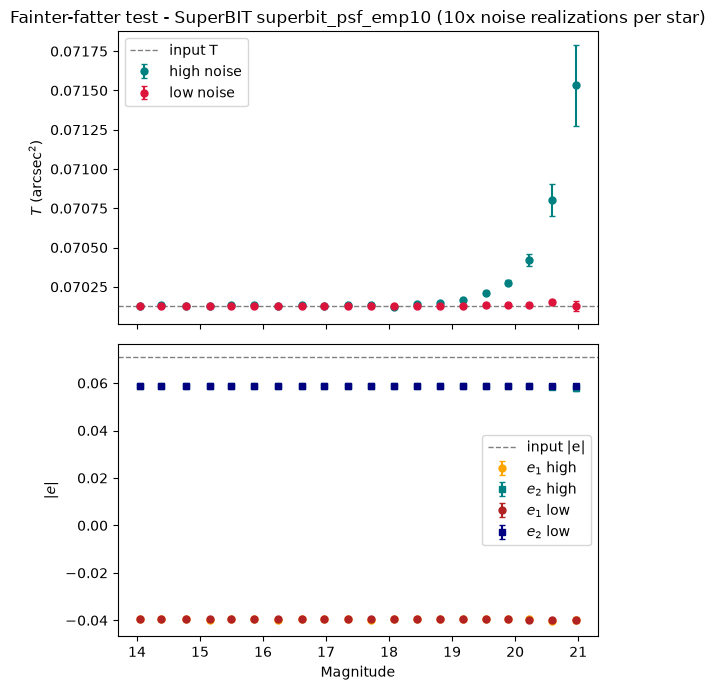

In [9]:
# plot: SuperBIT PSF version (cf. Fig. 9)
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(6, 7), sharex=True)

ax0.errorbar(mTs, Ts_med, yerr=Ts_err, fmt="o", color="teal", capsize=2, ms=5, label="high noise")
ax0.errorbar(mTs_lo, Ts_med_lo, yerr=Ts_err_lo, fmt="o", color="crimson", capsize=2, ms=5, label="low noise")
ax0.set_ylabel(r"$T$ (arcsec$^2$)")
ax0.set_title(f"Fainter-fatter test - SuperBIT {psf_label} ({N_REPS}x noise realizations per star)")
ax0.axhline(T_psf_input, color="gray", ls="--", lw=1, label="input T")
ax0.legend()

ax1.axhline(eabs_psf_input, color="gray", ls="--", lw=1, label="input |e|")
ax1.errorbar(m1s, e1s_med, yerr=e1s_err, fmt="o", color="orange", capsize=2, ms=5, label=r"$e_1$ high")
ax1.errorbar(m2s, e2s_med, yerr=e2s_err, fmt="s", color="teal",   capsize=2, ms=5, label=r"$e_2$ high")
ax1.errorbar(m1s_lo, e1s_med_lo, yerr=e1s_err_lo, fmt="o", color="firebrick", capsize=2, ms=5, label=r"$e_1$ low")
ax1.errorbar(m2s_lo, e2s_med_lo, yerr=e2s_err_lo, fmt="s", color="navy",      capsize=2, ms=5, label=r"$e_2$ low")
ax1.set_ylabel(r"$|e|$")
ax1.set_xlabel("Magnitude")
ax1.legend()

plt.tight_layout()
# plt.savefig(f"fainter_fatter_admom_test_superbit_{psf_label}_repeated.png", dpi=150, bbox_inches="tight")
print(f"Saved -> fainter_fatter_admom_test_superbit_{psf_label}_repeated.png")

Saved -> fainter_fatter_gauss_vs_superbit_repeated.png


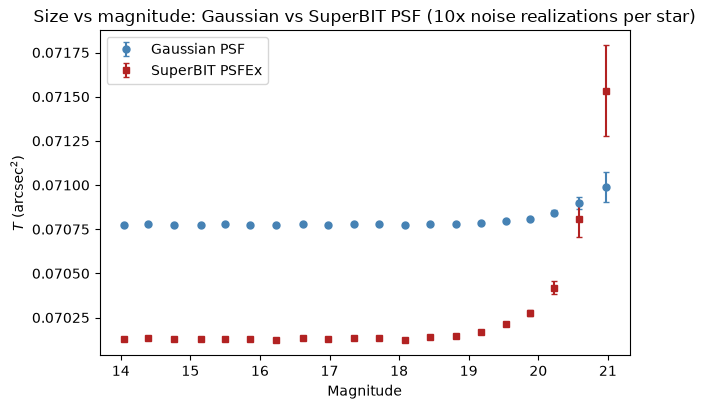

In [10]:
# direct comparison: T(mag) for Gaussian vs SuperBIT PSF
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.errorbar(mT,  T_med,  yerr=T_err,  fmt="o", color="steelblue", capsize=2, ms=5,
            label="Gaussian PSF")
ax.errorbar(mTs, Ts_med, yerr=Ts_err, fmt="s", color="firebrick", capsize=2, ms=5,
            label="SuperBIT PSFEx")
ax.set_xlabel("Magnitude")
ax.set_ylabel(r"$T$ (arcsec$^2$)")
ax.set_title(f"Size vs magnitude: Gaussian vs SuperBIT PSF ({N_REPS}x noise realizations per star)")
ax.legend()
plt.tight_layout()
# plt.savefig("fainter_fatter_gauss_vs_superbit_repeated.png", dpi=150, bbox_inches="tight")
print("Saved -> fainter_fatter_gauss_vs_superbit_repeated.png")

In [11]:
# save the binned points (mag, median, standard error)

# noise-free "input" values
gauss_T_input = get_admoms(
    galsim.Convolve([galsim.DeltaFunction(flux=1.0), psf])
          .drawImage(nx=STAMP, ny=STAMP, scale=PIXEL_SCALE).array,
    PIXEL_SCALE, reduced=True)["T"]
gauss_admom_psf_only = get_admoms(
    psf.drawImage(nx=STAMP, ny=STAMP, scale=PIXEL_SCALE).array,
    PIXEL_SCALE, reduced=True)
gauss_eabs_input = np.hypot(gauss_admom_psf_only["e1"], gauss_admom_psf_only["e2"])

# SuperBIT inputs already measured at selection time
superbit_T_input    = T_psf_input
superbit_eabs_input = eabs_psf_input

OUT_NPZ = f"fainter_fatter_binned_repeated_{psf_label}.npz"
np.savez(
    OUT_NPZ,
    N_REPS=N_REPS,
    # which SuperBIT PSF produced the superbit_* arrays, and the Fig. 9 target box
    psf_kind=PSF_KIND, psf_label=psf_label,
    T_target_range=np.asarray(T_TARGET_RANGE), e_target_range=np.asarray(E_TARGET_RANGE),
    # Gaussian PSF, high noise
    gauss_hi_mag=mT,   gauss_hi_T=T_med,     gauss_hi_T_err=T_err,
    gauss_hi_e_mag=mabs, gauss_hi_e=eabs_med, gauss_hi_e_err=eabs_err,
    # Gaussian PSF, low noise
    gauss_lo_mag=mT_lo,   gauss_lo_T=T_med_lo,     gauss_lo_T_err=T_err_lo,
    gauss_lo_e_mag=mabs_lo, gauss_lo_e=eabs_med_lo, gauss_lo_e_err=eabs_err_lo,
    # Gaussian PSF, noise-free input (admom on the noiseless image)
    gauss_T_input=gauss_T_input, gauss_eabs_input=gauss_eabs_input,
    # SuperBIT PSF, high noise
    superbit_hi_mag=mTs,   superbit_hi_T=Ts_med,     superbit_hi_T_err=Ts_err,
    superbit_hi_e_mag=mabs_s, superbit_hi_e=eabs_s_med, superbit_hi_e_err=eabs_s_err,
    # SuperBIT PSF, low noise
    superbit_lo_mag=mTs_lo, superbit_lo_T=Ts_med_lo, superbit_lo_T_err=Ts_err_lo,
    superbit_lo_e_mag=mabs_s_lo, superbit_lo_e=eabs_s_med_lo, superbit_lo_e_err=eabs_s_err_lo,
    # SuperBIT PSF, noise-free input (admom on the noiseless image)
    superbit_T_input=superbit_T_input, superbit_eabs_input=superbit_eabs_input,
)
print(f"Saved -> {OUT_NPZ}")

Saved -> fainter_fatter_binned_repeated_superbit_psf_emp10.npz
